# Notebook 03 — Neural Network from Scratch

This notebook is the conceptual bridge between the classical linear/kernel methods of
Notebooks 01-02 and the PyTorch networks in Notebooks 04-06.

We implement forward propagation and backpropagation **by hand**, with explicit NumPy
code for every derivative, for a tiny network:

```text
2 inputs
   |
   v
3 ReLU hidden units
   |
   v
1 linear output
```

PyTorch is not used anywhere in this notebook. The point is to see the chain rule at
work, not to train an accurate model.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from neural_networks.from_scratch import (
    NeuralNetwork,
    rectified_linear_unit,
    rectified_linear_unit_derivative,
    numerical_gradient_check,
)

np.random.seed(12321)

## 1. Network parameters and dimensions

The network has:

- an input $x\in\mathbb{R}^{2}$;
- a hidden layer with weights $W_1\in\mathbb{R}^{3\times2}$, bias $b_1\in\mathbb{R}^{3}$,
  and ReLU activation;
- an output layer with weights $W_2\in\mathbb{R}^{1\times3}$, bias $b_2\in\mathbb{R}$,
  and a linear (identity) activation.

We use a toy regression target: predict $y = x_1 + 2x_2$ from $x = (x_1, x_2)$. Any
function would do here; a simple linear target makes it easy to see whether training
succeeds.

In [2]:
net = NeuralNetwork(input_dim=2, hidden_dim=3, seed=12321)

print("W1 shape:", net.W1.shape)
print("b1 shape:", net.b1.shape)
print("W2 shape:", net.W2.shape)
print("b2 shape:", net.b2.shape)

W1 shape: (3, 2)
b1 shape: (3, 1)
W2 shape: (1, 3)
b2 shape: (1, 1)


## 2. Forward propagation

For a single input $x$:

$$
z_1 = W_1x + b_1, \qquad a_1=\text{ReLU}(z_1),
$$

$$
z_2 = W_2a_1 + b_2, \qquad \hat y = z_2 .
$$

`NeuralNetwork.forward` implements exactly these four lines and returns every
intermediate quantity, because backpropagation needs $z_1$, $a_1$, and $z_2$, not just
the final output $\hat y$.

In [3]:
x_example = np.array([1.0, 2.0])
cache = net.forward(x_example)
for key, value in cache.items():
    print(f"{key}: shape {np.asarray(value).shape}, value\n{value}\n")

x: shape (2, 1), value
[[1.]
 [2.]]

z1: shape (3, 1), value
[[-0.29133481]
 [ 0.29050543]
 [-1.33998086]]

a1: shape (3, 1), value
[[0.        ]
 [0.29050543]
 [0.        ]]

z2: shape (1, 1), value
[[0.27956802]]

y_hat: shape (1, 1), value
[[0.27956802]]



## 3. Loss

We use squared error,

$$
L = \tfrac{1}{2}(\hat y - y)^{2}.
$$

This loss is convenient here because its derivative with respect to $\hat y$ is simply
$\hat y - y$.

In [4]:
y_example = 1.0 * x_example[0] + 2.0 * x_example[1]
loss_value = net.loss(cache["y_hat"], y_example)
print("target y:", y_example)
print("y_hat:", float(np.asarray(cache["y_hat"]).ravel()[0]))
print("loss:", loss_value)

target y: 5.0
y_hat: 0.2795680205414462
loss: 11.1412390363475


## 4. Derivatives through the output layer

Since the output activation is the identity, $\dfrac{\partial \hat y}{\partial z_2}=1$,
so

$$
\frac{\partial L}{\partial z_2}=\frac{\partial L}{\partial \hat y}\cdot 1=\hat y - y .
$$

From there, the chain rule gives the gradients with respect to the output-layer
parameters:

$$
\frac{\partial L}{\partial W_2}=\frac{\partial L}{\partial z_2}\,a_1^{T}, \qquad
\frac{\partial L}{\partial b_2}=\frac{\partial L}{\partial z_2}.
$$

## 5. Derivative of ReLU

$$
\text{ReLU}(x)=\max(0,x), \qquad
\text{ReLU}'(x)=
\begin{cases}
1 & x>0\\
0 & x\le 0
\end{cases}
$$

We can see this directly on a small array of inputs.

ReLU:             [0.  0.  0.  0.5 2. ]
ReLU derivative:  [0. 0. 0. 1. 1.]


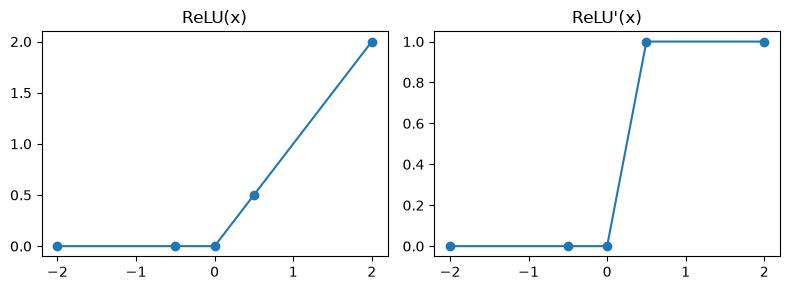

In [5]:
test_inputs = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
print("ReLU:            ", rectified_linear_unit(test_inputs))
print("ReLU derivative: ", rectified_linear_unit_derivative(test_inputs))

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(test_inputs, rectified_linear_unit(test_inputs), marker="o")
plt.title("ReLU(x)")
plt.subplot(1, 2, 2)
plt.plot(test_inputs, rectified_linear_unit_derivative(test_inputs), marker="o")
plt.title("ReLU'(x)")
plt.tight_layout()
plt.show()

## 6. Backpropagation through the hidden layer

The output-layer gradient is propagated back to the hidden layer through $W_2$, then
through the ReLU derivative:

$$
\frac{\partial L}{\partial a_1}=W_2^{T}\frac{\partial L}{\partial z_2}, \qquad
\frac{\partial L}{\partial z_1}=\frac{\partial L}{\partial a_1}\odot \text{ReLU}'(z_1),
$$

and finally

$$
\frac{\partial L}{\partial W_1}=\frac{\partial L}{\partial z_1}\,x^{T}, \qquad
\frac{\partial L}{\partial b_1}=\frac{\partial L}{\partial z_1}.
$$

`NeuralNetwork.backward` implements exactly this sequence of five lines, using the
cache returned by `forward`.

In [6]:
grads = net.backward(cache, y_example)
for key, value in grads.items():
    print(f"{key}: shape {value.shape}")

dW1: shape (3, 2)
db1: shape (3, 1)
dW2: shape (1, 3)
db2: shape (1, 1)


## 7. Gradient-descent update

Each parameter is updated by a small step opposite its gradient:

$$
\theta \leftarrow \theta - \eta\,\frac{\partial L}{\partial \theta}.
$$

`NeuralNetwork.step` applies this update to $W_1, b_1, W_2, b_2$ using the gradients
computed above.

In [7]:
before = net.loss(net.forward(x_example)["y_hat"], y_example)
net.step(grads, learning_rate=0.05)
after = net.loss(net.forward(x_example)["y_hat"], y_example)
print(f"loss before one gradient step: {before:.4f}")
print(f"loss after  one gradient step: {after:.4f}")

loss before one gradient step: 11.1412
loss after  one gradient step: 4.6804


## 8. Repeated training

We now train on a small synthetic dataset of $(x, y)$ pairs generated from
$y = x_1 + 2x_2$ plus a little noise, and track the loss over training.

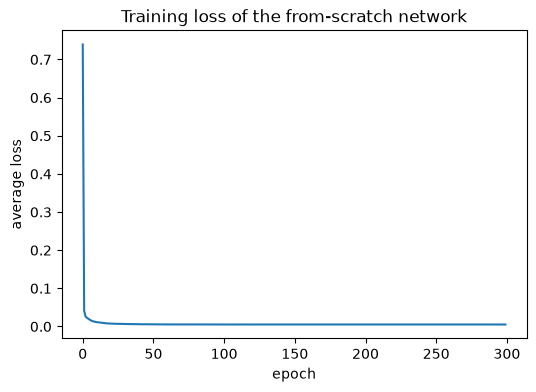

first-epoch loss: 0.7392787243599251
last-epoch loss:  0.005207790101687756


In [8]:
rng = np.random.RandomState(0)
X_train = rng.uniform(-2, 2, size=(200, 2))
Y_train = X_train[:, 0] + 2 * X_train[:, 1] + rng.normal(scale=0.1, size=200)

net = NeuralNetwork(input_dim=2, hidden_dim=3, seed=12321)
loss_history = net.train(X_train, Y_train, learning_rate=0.01, epochs=300)

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("average loss")
plt.title("Training loss of the from-scratch network")
plt.show()

print("first-epoch loss:", loss_history[0])
print("last-epoch loss: ", loss_history[-1])

## 9. Numerical gradient check

As a sanity check on the backpropagation derivation, we compare the analytic gradient
against a **centered finite-difference approximation**,

$$
\frac{\partial L}{\partial\theta}\approx\frac{L(\theta+\epsilon)-L(\theta-\epsilon)}{2\epsilon},
$$

for one entry of $W_1$. If the derivation and implementation above are correct, the
two values should agree closely.

In [9]:
x_check, y_check = X_train[0], Y_train[0]
numeric_grad, analytic_grad = numerical_gradient_check(net, x_check, y_check, "W1", (0, 0))
print(f"numeric gradient:  {numeric_grad:.6f}")
print(f"analytic gradient: {analytic_grad:.6f}")
print(f"absolute difference: {abs(numeric_grad - analytic_grad):.2e}")

numeric gradient:  0.000000
analytic gradient: 0.000000
absolute difference: 0.00e+00


## Study questions

1. Where is the chain rule used?
2. What does each gradient tell us?
3. Why does ReLU make the hidden layer nonlinear?
4. What would happen if the hidden layer were removed?